# Model Comparison — RF / XGBoost / LightGBM / SVM on Original vs SMOTE vs ADASYN vs CTGAN

Trains 4 classifiers on 4 dataset variants (Original, SMOTE, ADASYN, CTGAN) from
`shanmukhadattaboda/malmem-augmneted-5-class-datasets` and compares them on Accuracy, Macro-F1,
Weighted-F1, MCC, ROC-AUC, and PR-AUC.

**Read this before running:** I have not been able to inspect this dataset's actual file names or
column structure. So Section 2 below **downloads the dataset and prints exactly what it finds** —
file names, and (for each file) the columns and target candidates — before anything else runs. Run
that cell first and check the printed output. If the automatic variant-matching or target-column
detection picks the wrong thing, tell me exactly what got printed and I'll fix the one line that
needs it, rather than you debugging blind.


## 1. Install & Import

In [ ]:
# On Kaggle: xgboost and lightgbm are preinstalled. On a local IDE, uncomment:
# pip install kagglehub[pandas-datasets] xgboost lightgbm scikit-learn pandas numpy

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import kagglehub

print("Imports OK.")


Imports OK.


## 2. Load Dataset — self-discovering (prints what it finds, does not assume file names)

Downloads the full dataset folder, lists every `.csv`/`.parquet` file, and tries to match each file
to one of the 4 variants by filename keyword (`original`, `smote`, `adasyn`, `ctgan`). If the dataset
is actually a single file with a column that labels the technique (e.g. `dataset_type` / `method` /
`source`), it detects that instead. Either way, the printed output tells you exactly what happened.


In [ ]:
dataset_dir = kagglehub.dataset_download("shanmukhadattaboda/malmem-augmneted-5-class-datasets")
print("Dataset downloaded/attached at:", dataset_dir)

data_files = []
for root, _, files in os.walk(dataset_dir):
    for fname in files:
        if fname.lower().endswith((".csv", ".parquet")):
            data_files.append(os.path.join(root, fname))

print(f"\nFound {len(data_files)} data file(s):")
for f in data_files:
    print(" -", f)


Dataset downloaded/attached at: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets

Found 7 data file(s):
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_cGAN_balanced.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_SMOTE.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_TVAE_balanced.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_ADASYN.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_CTGAN_balanced.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_BorderlineSMOTE.csv
 - /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022.csv


In [ ]:
VARIANT_KEYWORDS = {
    "Original": ["original", "orig", "raw"],
    "SMOTE": ["smote"],
    "ADASYN": ["adasyn"],
    "CTGAN": ["ctgan", "gan"],
}

def match_variant(filename):
    lower = filename.lower()
    for variant, keywords in VARIANT_KEYWORDS.items():
        if any(k in lower for k in keywords):
            return variant
    return None

variant_frames = {}

if len(data_files) > 1:
    # Multiple files -> match each to a variant by filename
    for f in data_files:
        variant = match_variant(os.path.basename(f))
        frame = pd.read_parquet(f) if f.lower().endswith(".parquet") else pd.read_csv(f)
        if variant is None:
            print(f"Could not match '{os.path.basename(f)}' to a known variant by filename -- "
                  f"inspect this file's name/content and tell me which variant it is.")
            variant = os.path.basename(f)  # fall back to using the raw filename as the label
        variant_frames[variant] = frame
        print(f"'{os.path.basename(f)}' -> variant '{variant}', shape {frame.shape}")
else:
    # Single file -> look for a column that labels the augmentation technique
    single_df = pd.read_parquet(data_files[0]) if data_files[0].lower().endswith(".parquet") else pd.read_csv(data_files[0])
    print("Single file loaded, shape:", single_df.shape)
    print("Columns:", single_df.columns.tolist())

    method_col_candidates = [c for c in single_df.columns if c.lower() in
                              ("dataset_type", "method", "source", "technique", "augmentation", "variant")]
    if method_col_candidates:
        method_col = method_col_candidates[0]
        print(f"\nDetected variant-labeling column: '{method_col}' -> unique values: {single_df[method_col].unique()}")
        for val in single_df[method_col].unique():
            matched = match_variant(str(val)) or str(val)
            variant_frames[matched] = single_df[single_df[method_col] == val].drop(columns=[method_col])
    else:
        print("\n*** Could not find a variant-labeling column either. ***")
        print("Treating the whole file as 'Original' -- if it actually contains all 4 variants mixed")
        print("together, tell me the column list above and I'll fix the split logic directly.")
        variant_frames["Original"] = single_df

print("\nFinal variants loaded:", {k: v.shape for k, v in variant_frames.items()})


'MalMem2022_cGAN_balanced.csv' -> variant 'CTGAN', shape (116924, 56)
'MalMem2022_SMOTE.csv' -> variant 'SMOTE', shape (117192, 56)
Could not match 'MalMem2022_TVAE_balanced.csv' to a known variant by filename -- inspect this file's name/content and tell me which variant it is.
'MalMem2022_TVAE_balanced.csv' -> variant 'MalMem2022_TVAE_balanced.csv', shape (116924, 56)
'MalMem2022_ADASYN.csv' -> variant 'ADASYN', shape (117707, 56)
'MalMem2022_CTGAN_balanced.csv' -> variant 'CTGAN', shape (116924, 56)
'MalMem2022_BorderlineSMOTE.csv' -> variant 'SMOTE', shape (117192, 56)
Could not match 'MalMem2022.csv' to a known variant by filename -- inspect this file's name/content and tell me which variant it is.
'MalMem2022.csv' -> variant 'MalMem2022.csv', shape (58596, 56)

Final variants loaded: {'CTGAN': (116924, 56), 'SMOTE': (117192, 56), 'MalMem2022_TVAE_balanced.csv': (116924, 56), 'ADASYN': (117707, 56), 'MalMem2022.csv': (58596, 56)}


## 3. Identify Target Column (auto-detected, same logic across all variants)

In [ ]:
TARGET_CANDIDATES = ["Category", "category", "Class", "class", "label", "Label", "target", "Target"]

def find_target(frame):
    for c in TARGET_CANDIDATES:
        if c in frame.columns:
            return c
    # fallback: lowest-cardinality object/categorical column
    obj_cols = frame.select_dtypes(include=["object", "category"]).columns.tolist()
    if obj_cols:
        return min(obj_cols, key=lambda c: frame[c].nunique())
    raise ValueError("Could not auto-detect a target column -- check frame.columns manually.")

TARGET = find_target(next(iter(variant_frames.values())))
print("Detected target column:", TARGET)

for name, frame in variant_frames.items():
    print(f"{name}: shape={frame.shape}, classes={sorted(frame[TARGET].unique().tolist())}")


Detected target column: Label
CTGAN: shape=(116924, 56), classes=['Benign', 'Ransomware', 'Spyware', 'Trojan']
SMOTE: shape=(117192, 56), classes=['Benign', 'Ransomware', 'Spyware', 'Trojan']
MalMem2022_TVAE_balanced.csv: shape=(116924, 56), classes=['Benign', 'Ransomware', 'Spyware', 'Trojan']
ADASYN: shape=(117707, 56), classes=['Benign', 'Ransomware', 'Spyware', 'Trojan']
MalMem2022.csv: shape=(58596, 56), classes=['Benign', 'Ransomware', 'Spyware', 'Trojan']


## 4. Models & Metrics Setup

Kept intentionally simple/fast: default-ish hyperparameters, one shared train/test split per variant
(80/20, stratified), one StandardScaler per variant (fit on that variant's train split only). SVM
gets a row cap since `probability=True` (needed for ROC-AUC/PR-AUC) makes it the slowest model by far.


In [ ]:
MAX_SVM_TRAIN_ROWS = 15000   # keep SVM fast; raise this if you want more accuracy at the cost of time

def get_models():
    return {
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=200, use_label_encoder=False, eval_metric="mlogloss",
            random_state=42, n_jobs=-1, verbosity=0
        ),
        "LightGBM": LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbosity=-1),
        "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    }

def compute_metrics(y_true, y_pred, y_proba, classes):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted"),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    try:
        y_true_bin = label_binarize(y_true, classes=classes)
        if y_true_bin.shape[1] == 1:  # binary edge case
            y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])
        metrics["ROC_AUC"] = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
        metrics["PR_AUC"] = average_precision_score(y_true_bin, y_proba, average="macro")
    except Exception as e:
        metrics["ROC_AUC"] = np.nan
        metrics["PR_AUC"] = np.nan
        print(f"  (ROC-AUC/PR-AUC skipped: {e})")
    return metrics

print("Model/metric helpers ready.")


Model/metric helpers ready.


## 5. Train & Evaluate All (Model x Variant) Combinations

In [ ]:
results = []

for variant_name, frame in variant_frames.items():
    print(f"\n=== Variant: {variant_name} ({frame.shape[0]} rows) ===")

    X = frame.drop(columns=[TARGET])
    X = X.select_dtypes(include=[np.number])  # keep it simple: numeric features only
    y_raw = frame[TARGET]

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    classes = list(range(len(le.classes_)))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = get_models()
    for model_name, model in models.items():
        print(f"  Training {model_name}...")

        if model_name == "SVM" and len(X_train_scaled) > MAX_SVM_TRAIN_ROWS:
            idx = np.random.RandomState(42).choice(len(X_train_scaled), MAX_SVM_TRAIN_ROWS, replace=False)
            model.fit(X_train_scaled[idx], y_train[idx])
        else:
            model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)

        metrics = compute_metrics(y_test, y_pred, y_proba, classes)
        metrics["Variant"] = variant_name
        metrics["Model"] = model_name
        results.append(metrics)

results_df = pd.DataFrame(results)[["Variant", "Model", "Accuracy", "Macro_F1", "Weighted_F1", "MCC", "ROC_AUC", "PR_AUC"]]
print("\nAll combinations trained.")



=== Variant: CTGAN (116924 rows) ===
  Training RandomForest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

=== Variant: SMOTE (117192 rows) ===
  Training RandomForest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

=== Variant: MalMem2022_TVAE_balanced.csv (116924 rows) ===
  Training RandomForest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

=== Variant: ADASYN (117707 rows) ===
  Training RandomForest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

=== Variant: MalMem2022.csv (58596 rows) ===
  Training RandomForest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

All combinations trained.


## 6. Results Table

In [ ]:
results_df_sorted = results_df.sort_values(["Variant", "Macro_F1"], ascending=[True, False]).reset_index(drop=True)
display(results_df_sorted)


,Variant,Model,Accuracy,Macro_F1,Weighted_F1,MCC,ROC_AUC,PR_AUC
0,ADASYN,RandomForest,0.923244,0.923395,0.923200,0.897693,0.988882,0.969125
1,ADASYN,XGBoost,0.855237,0.855280,0.854862,0.807238,0.969271,0.919727
2,ADASYN,LightGBM,0.821723,0.821747,0.821258,0.762613,0.956002,0.886050
3,ADASYN,SVM,0.585719,0.577236,0.576891,0.456577,0.816649,0.596879
4,CTGAN,RandomForest,0.623519,0.623525,0.623520,0.498266,0.852388,0.686143
5,CTGAN,LightGBM,0.615737,0.615742,0.615737,0.487723,0.844572,0.670035
6,CTGAN,XGBoost,0.613598,0.613601,0.613596,0.484815,0.842250,0.665230
7,CTGAN,SVM,0.552448,0.547989,0.547981,0.407243,0.792039,0.557009
8,MalMem2022.csv,XGBoost,0.880034,0.819102,0.879688,0.820137,0.973242,0.888245
9,MalMem2022.csv,LightGBM,0.875512,0.812214,0.875135,0.813351,0.971596,0.881054


## 7. Comparison Charts

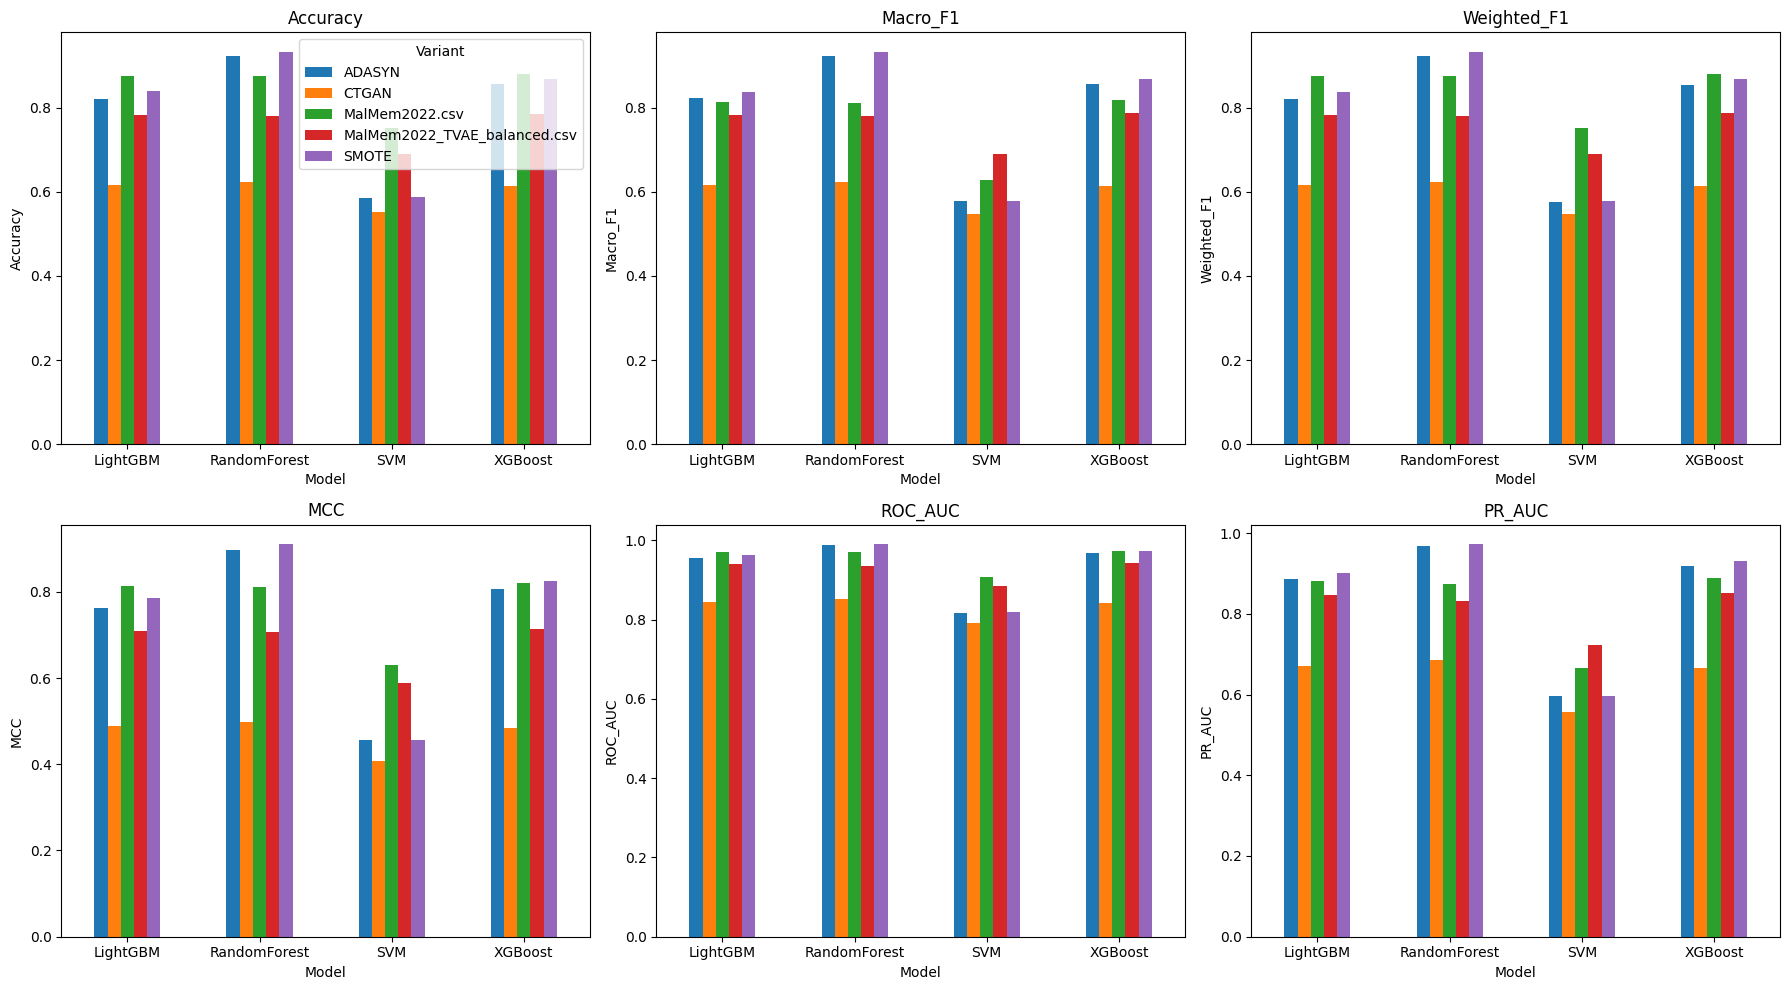

In [ ]:
metrics_to_plot = ["Accuracy", "Macro_F1", "Weighted_F1", "MCC", "ROC_AUC", "PR_AUC"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    pivot = results_df.pivot(index="Model", columns="Variant", values=metric)
    pivot.plot(kind="bar", ax=ax, legend=(metric == "Accuracy"))
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 8. Best Combination Per Metric

In [ ]:
for metric in metrics_to_plot:
    best_row = results_df.loc[results_df[metric].idxmax()]
    print(f"Best {metric}: {best_row['Model']} on {best_row['Variant']}  ->  {best_row[metric]:.4f}")


Best Accuracy: RandomForest on SMOTE  ->  0.9324
Best Macro_F1: RandomForest on SMOTE  ->  0.9324
Best Weighted_F1: RandomForest on SMOTE  ->  0.9324
Best MCC: RandomForest on SMOTE  ->  0.9099
Best ROC_AUC: RandomForest on SMOTE  ->  0.9899
Best PR_AUC: RandomForest on SMOTE  ->  0.9719


## 9. Save Results

In [ ]:
os.makedirs("results", exist_ok=True)
results_df_sorted.to_csv("results/model_comparison_results.csv", index=False)
print("Saved results/model_comparison_results.csv")


Saved results/model_comparison_results.csv
